In [ ]:
# --- Step 1: setup & load ---
from google.colab import files
uploaded = files.upload()

Saving auto_claims_dataset.csv to auto_claims_dataset.csv


In [ ]:
import pandas as pd
import numpy as np


# Load
df = pd.read_csv("auto_claims_dataset.csv")

# Peek
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nHead:")
display(df.head())

print("\nInfo:")
print(df.info())

print("\nMissing values per column:")
print(df.isna().sum())

print("\nBasic numeric summary:")
display(df.describe())

Shape: (50000, 9)

Columns: ['policy_id', 'exposure', 'age', 'vehicle_age', 'region', 'vehicle_type', 'premium', 'n_claims', 'claim_amount']

Head:


,policy_id,exposure,age,vehicle_age,region,vehicle_type,premium,n_claims,claim_amount
0,33554,0.64,30,10,East,Sedan,709.51,0,0.000000
1,9428,0.92,19,4,North,Hatchback,1343.43,0,0.000000
2,200,0.89,42,16,North,Sedan,1726.33,0,0.000000
3,12448,1.00,55,2,East,SUV,634.92,2,2290.540556
4,39490,0.80,44,8,West,Sedan,688.18,0,0.000000



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   policy_id     50000 non-null  int64  
 1   exposure      50000 non-null  float64
 2   age           50000 non-null  int64  
 3   vehicle_age   50000 non-null  int64  
 4   region        50000 non-null  object 
 5   vehicle_type  50000 non-null  object 
 6   premium       50000 non-null  float64
 7   n_claims      50000 non-null  int64  
 8   claim_amount  50000 non-null  float64
dtypes: float64(3), int64(4), object(2)
memory usage: 3.4+ MB
None

Missing values per column:
policy_id       0
exposure        0
age             0
vehicle_age     0
region          0
vehicle_type    0
premium         0
n_claims        0
claim_amount    0
dtype: int64

Basic numeric summary:


,policy_id,exposure,age,vehicle_age,premium,n_claims,claim_amount
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,0.749429,48.566180,9.508160,1150.004336,0.207040,208.170468
std,14433.901067,0.144253,17.816613,5.759309,491.672329,0.454509,579.787590
min,1.000000,0.500000,18.000000,0.000000,300.020000,0.000000,0.000000
25%,12500.750000,0.620000,33.000000,5.000000,722.172500,0.000000,0.000000
50%,25000.500000,0.750000,49.000000,10.000000,1150.705000,0.000000,0.000000
75%,37500.250000,0.870000,64.000000,14.000000,1576.462500,0.000000,0.000000
max,50000.000000,1.000000,79.000000,19.000000,1999.930000,5.000000,11636.453040



Unique regions: ['East', 'North', 'West', 'South']
Categories (4, object): ['East', 'North', 'South', 'West']
Unique vehicle types: ['Sedan', 'Hatchback', 'SUV', 'Truck']
Categories (4, object): ['Hatchback', 'SUV', 'Sedan', 'Truck']
Min/Max of numeric columns:
     exposure  age  vehicle_age  premium  n_claims  claim_amount
min       0.5   18            0   300.02         0       0.00000
max       1.0   79           19  1999.93         5   11636.45304


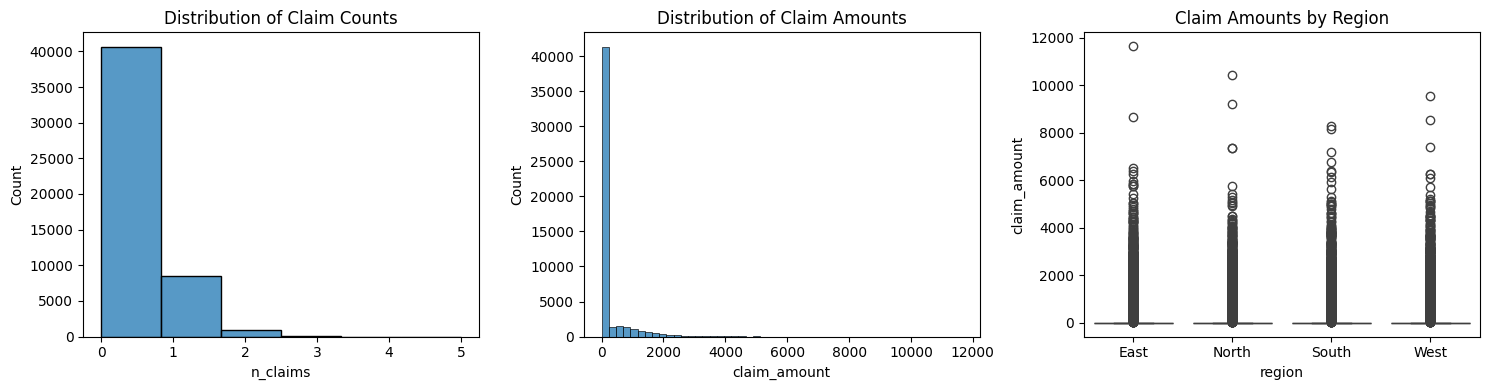


Average claim frequency by region & vehicle type:


/tmp/ipython-input-230751387.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  freq_summary = df.groupby(['region','vehicle_type'])['n_claims'].mean().unstack()


vehicle_type,Hatchback,SUV,Sedan,Truck
region,,,,
East,0.207,0.216,0.193,0.211
North,0.218,0.209,0.216,0.206
South,0.204,0.204,0.203,0.204
West,0.217,0.207,0.200,0.197


In [ ]:
# --- Step 2: data cleaning & exploratory setup ---

import matplotlib.pyplot as plt
import seaborn as sns

# Convert region and vehicle_type to category dtype
df['region'] = df['region'].astype('category')
df['vehicle_type'] = df['vehicle_type'].astype('category')

# Quick logic checks
print("\nUnique regions:", df['region'].unique())
print("Unique vehicle types:", df['vehicle_type'].unique())
print("Min/Max of numeric columns:")
print(df[['exposure','age','vehicle_age','premium','n_claims','claim_amount']].agg(['min','max']))

# Sanity plots
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['n_claims'], bins=6, ax=axs[0])
axs[0].set_title('Distribution of Claim Counts')

sns.histplot(df['claim_amount'], bins=50, ax=axs[1])
axs[1].set_title('Distribution of Claim Amounts')

sns.boxplot(x='region', y='claim_amount', data=df, ax=axs[2])
axs[2].set_title('Claim Amounts by Region')
plt.tight_layout()
plt.show()

# Claim frequency by region and vehicle type
freq_summary = df.groupby(['region','vehicle_type'])['n_claims'].mean().unstack()
print("\nAverage claim frequency by region & vehicle type:")
display(freq_summary.round(3))

In [ ]:
# --- Step 3: Feature Engineering for Modeling ---

# Create age and vehicle_age bands
age_bins = [17, 25, 35, 45, 55, 65, 80]
age_labels = ['<25','25-34','35-44','45-54','55-64','65+']
df['age_band'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=True)

veh_bins = [-1, 3, 7, 12, 20]
veh_labels = ['<=3','4-7','8-12','13+']
df['veh_age_band'] = pd.cut(df['vehicle_age'], bins=veh_bins, labels=veh_labels, right=True)

# Log transform premium (to reduce skew)
df['log_premium'] = np.log1p(df['premium'])

# Create frequency and severity subsets
# frequency: use all rows (response = n_claims)
# severity: only where claims occurred
freq_df = df.copy()
sev_df = df[df['n_claims'] > 0].copy()
sev_df['avg_severity'] = sev_df['claim_amount'] / sev_df['n_claims']

# Quick sanity check
print("Frequency dataset shape:", freq_df.shape)
print("Severity dataset shape:", sev_df.shape)
print("\nPreview of frequency data:")
display(freq_df.head(3))
print("\nPreview of severity data:")
display(sev_df.head(3))

Frequency dataset shape: (50000, 12)
Severity dataset shape: (9359, 13)

Preview of frequency data:


,policy_id,exposure,age,vehicle_age,region,vehicle_type,premium,n_claims,claim_amount,age_band,veh_age_band,log_premium
0,33554,0.64,30,10,East,Sedan,709.51,0,0.0,25-34,8-12,6.565983
1,9428,0.92,19,4,North,Hatchback,1343.43,0,0.0,<25,4-7,7.203725
2,200,0.89,42,16,North,Sedan,1726.33,0,0.0,35-44,13+,7.454332



Preview of severity data:


,policy_id,exposure,age,vehicle_age,region,vehicle_type,premium,n_claims,claim_amount,age_band,veh_age_band,log_premium,avg_severity
3,12448,1.00,55,2,East,SUV,634.92,2,2290.540556,45-54,<=3,6.455073,1145.270278
6,10823,0.98,66,15,West,Hatchback,1184.02,1,889.422472,65+,13+,7.077515,889.422472
8,4145,0.96,74,1,West,Sedan,1015.27,1,735.192617,65+,<=3,6.923894,735.192617


In [ ]:
# --- Step 4: Frequency GLM (Poisson) ---

import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np

# Create offset = log(exposure)
freq_df['log_exposure'] = np.log(freq_df['exposure'])

# Define model formula
formula = """
n_claims ~ C(region) + C(vehicle_type) + C(age_band) + C(veh_age_band) + log_premium
"""

# Fit Poisson GLM with log link and offset(log_exposure)
poisson_model = smf.glm(
    formula=formula,
    data=freq_df,
    family=sm.families.Poisson(),
    offset=freq_df['log_exposure']
).fit()

# Display model summary
print(poisson_model.summary())

# Calculate predicted frequency
freq_df['freq_pred'] = poisson_model.predict(freq_df, offset=freq_df['log_exposure'])

# Quick check of predictions vs observed
obs_mean = (freq_df['n_claims'] / freq_df['exposure']).mean()
pred_mean = freq_df['freq_pred'].mean()

print(f"\nObserved mean frequency per exposure: {obs_mean:.4f}")
print(f"Predicted mean frequency per exposure: {pred_mean:.4f}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:               n_claims   No. Observations:                50000
Model:                            GLM   Df Residuals:                    49984
Model Family:                 Poisson   Df Model:                           15
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -27566.
Date:                Sun, 09 Nov 2025   Deviance:                       35820.
Time:                        21:05:54   Pearson chi2:                 5.23e+04
No. Iterations:                     6   Pseudo R-squ. (CS):          0.0001948
Covariance Type:            nonrobust                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

Overdispersion ratio (variance / mean): 1.00

Observed vs Predicted frequency by region:


/tmp/ipython-input-4121357337.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  freq_df.groupby('region')[['n_claims', 'exposure', 'freq_pred']]


,observed_rate,freq_pred
region,,
East,0.2765,0.2069
North,0.2833,0.2123
South,0.2719,0.2037
West,0.2734,0.2053


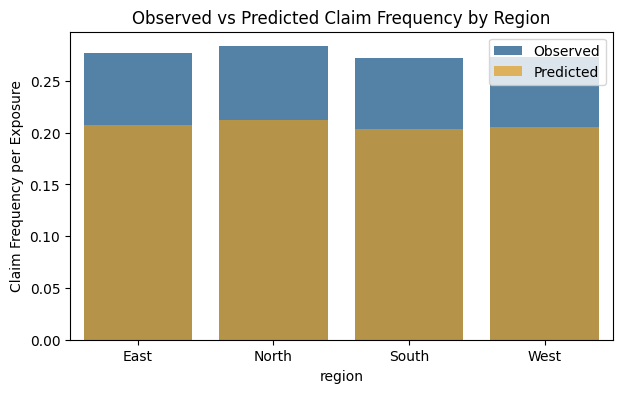

In [ ]:
# --- Step 5: Overdispersion & Diagnostics ---

# Overdispersion ratio
mean_claims = freq_df['n_claims'].mean()
var_claims = freq_df['n_claims'].var()
overdispersion_ratio = var_claims / mean_claims
print(f"Overdispersion ratio (variance / mean): {overdispersion_ratio:.2f}")

# Observed vs Predicted frequency by region
region_summary = (
    freq_df.groupby('region')[['n_claims', 'exposure', 'freq_pred']]
    .agg({'n_claims':'sum', 'exposure':'sum', 'freq_pred':'mean'})
)
region_summary['observed_rate'] = region_summary['n_claims'] / region_summary['exposure']

print("\nObserved vs Predicted frequency by region:")
display(region_summary[['observed_rate','freq_pred']].round(4))

# Visual diagnostic
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,4))
sns.barplot(x=region_summary.index, y=region_summary['observed_rate'], color='steelblue', label='Observed')
sns.barplot(x=region_summary.index, y=region_summary['freq_pred'], color='orange', alpha=0.7, label='Predicted')
plt.title("Observed vs Predicted Claim Frequency by Region")
plt.ylabel("Claim Frequency per Exposure")
plt.legend()
plt.show()

In [ ]:
# --- Step 6: Severity GLM (Gamma) ---

# Filtered dataset with only claimants
print("Rows with at least one claim:", sev_df.shape[0])

# Gamma GLM to predict average severity
formula_sev = """
avg_severity ~ C(region) + C(vehicle_type) + C(age_band) + C(veh_age_band) + log_premium
"""

gamma_model = smf.glm(
    formula=formula_sev,
    data=sev_df,
    family=sm.families.Gamma(sm.families.links.log())
).fit()

print(gamma_model.summary())

# Add predictions to the dataframe
sev_df['sev_pred'] = gamma_model.predict(sev_df)

# Compare observed vs predicted severity by region
sev_summary = (
    sev_df.groupby('region')[['avg_severity','sev_pred']]
    .mean()
    .rename(columns={'avg_severity':'observed','sev_pred':'predicted'})
)

print("\nObserved vs Predicted Average Severity by Region:")
display(sev_summary.round(2))

Rows with at least one claim: 9359


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


                 Generalized Linear Model Regression Results                  
Dep. Variable:           avg_severity   No. Observations:                 9359
Model:                            GLM   Df Residuals:                     9343
Model Family:                   Gamma   Df Model:                           15
Link Function:                    log   Scale:                         0.49653
Method:                          IRLS   Log-Likelihood:                -72937.
Date:                Sun, 09 Nov 2025   Deviance:                       5025.0
Time:                        21:57:25   Pearson chi2:                 4.64e+03
No. Iterations:                    10   Pseudo R-squ. (CS):           0.001494
Covariance Type:            nonrobust                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

/tmp/ipython-input-410567356.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sev_df.groupby('region')[['avg_severity','sev_pred']]


,observed,predicted
region,,
East,1012.08,1012.49
North,984.32,984.13
South,1015.99,1016.11
West,1003.01,1002.70



Expected Pure Premium by Region:


/tmp/ipython-input-1600461000.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged.groupby('region')[['pure_premium_pred']]


,expected_pure_premium
region,
East,207.97
North,212.32
South,204.89
West,205.98


/tmp/ipython-input-1600461000.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pp_summary.index, y=pp_summary['expected_pure_premium'], palette="viridis")


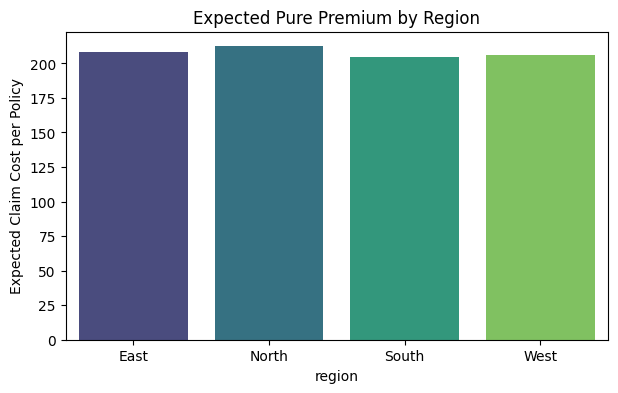

In [ ]:
# --- Step 7: Combine Frequency & Severity Models ---

# Merge predicted frequency and severity by policy_id
merged = freq_df[['policy_id','region','vehicle_type','age_band','veh_age_band','exposure','freq_pred']].merge(
    sev_df[['policy_id','sev_pred']], on='policy_id', how='left'
)

# Fill missing severity predictions (for policies with no claim) with average predicted severity
merged['sev_pred'] = merged['sev_pred'].fillna(sev_df['sev_pred'].mean())

# Calculate Pure Premium = freq_pred × sev_pred
merged['pure_premium_pred'] = merged['freq_pred'] * merged['sev_pred']

# Observed pure premium per exposure
merged['pure_premium_obs'] = merged['exposure'] * merged['freq_pred'] * merged['sev_pred']

# Exposure-weighted summary by region
pp_summary = (
    merged.groupby('region')[['pure_premium_pred']]
    .mean()
    .rename(columns={'pure_premium_pred':'expected_pure_premium'})
)

print("\nExpected Pure Premium by Region:")
display(pp_summary.round(2))

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,4))
sns.barplot(x=pp_summary.index, y=pp_summary['expected_pure_premium'], palette="viridis")
plt.title("Expected Pure Premium by Region")
plt.ylabel("Expected Claim Cost per Policy")
plt.show()

/tmp/ipython-input-209989948.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  lift = merged.groupby('bucket').apply(


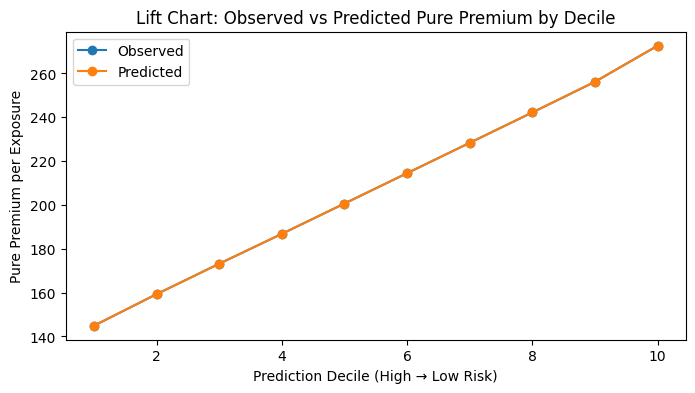

In [ ]:
# --- Lift Chart for Pure Premium Predictions ---

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

merged['bucket'] = pd.qcut(merged['pure_premium_pred'], q=10, labels=False)
lift = merged.groupby('bucket').apply(
    lambda g: pd.Series({
        'obs_pp': np.sum(g['pure_premium_obs'])/np.sum(g['exposure']),
        'pred_pp': np.sum(g['pure_premium_pred']*g['exposure'])/np.sum(g['exposure']),
        'exposure': g['exposure'].sum()
    })
).reset_index()

plt.figure(figsize=(8,4))
plt.plot(lift['bucket']+1, lift['obs_pp'], marker='o', label='Observed')
plt.plot(lift['bucket']+1, lift['pred_pp'], marker='o', label='Predicted')
plt.title("Lift Chart: Observed vs Predicted Pure Premium by Decile")
plt.xlabel("Prediction Decile (High → Low Risk)")
plt.ylabel("Pure Premium per Exposure")
plt.legend()
plt.show()

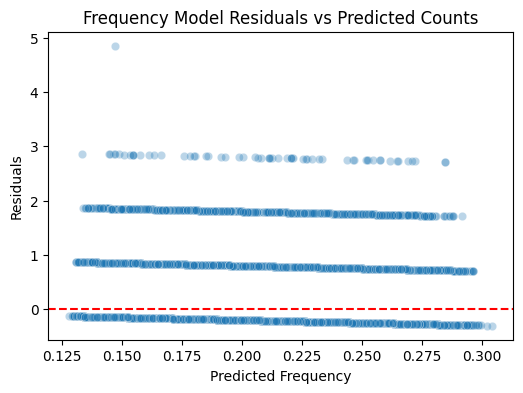

In [ ]:
# --- Residual Diagnostics for Frequency Model ---

freq_df['residuals'] = freq_df['n_claims'] - freq_df['freq_pred']
plt.figure(figsize=(6,4))
sns.scatterplot(x=freq_df['freq_pred'], y=freq_df['residuals'], alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title("Frequency Model Residuals vs Predicted Counts")
plt.xlabel("Predicted Frequency")
plt.ylabel("Residuals")
plt.show()

/tmp/ipython-input-1228217110.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=relativity.index, y=relativity.values, palette="mako")


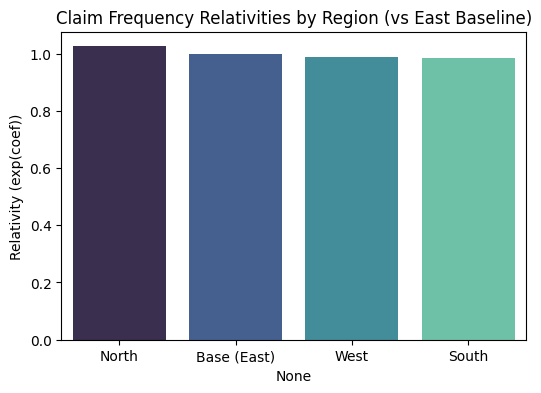

In [ ]:
# --- Relativity Chart for Region ---

region_coef = poisson_model.params.filter(like='C(region)')
relativity = np.exp(region_coef)
relativity.index = relativity.index.str.replace('C(region)[T.', '').str.replace(']', '')
relativity.loc['Base (East)'] = 1.0

relativity = relativity.sort_values(ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(x=relativity.index, y=relativity.values, palette="mako")
plt.title("Claim Frequency Relativities by Region (vs East Baseline)")
plt.ylabel("Relativity (exp(coef))")
plt.show()